# 02 — Demand Forecasting & Machine Learning Engine
### Dynamic Pricing & Revenue Intelligence System | Final Year B.Tech Project
---
**Objective:** Build, benchmark, and validate leakage-free regression models to predict unit demand as a function of time, historical sales patterns, price levels, competitor pricing, and promotions.


In [1]:
import os
import sys
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate

# Add project root to path
sys.path.append(os.path.abspath("."))
from src.data_loader import load_data, clean_data
from src.feature_engineering import (
    create_time_features,
    create_lag_and_rolling_features,
    create_pricing_features,
    build_feature_pipeline
)
from src.modeling import (
    chronological_train_val_test_split,
    calculate_metrics,
    train_baseline_models,
    train_random_forest,
    train_xgboost,
    save_model_artifacts
)

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 120


## 1. Feature Engineering (Strictly Leakage-Free)
We extract time seasonality features, calculate historical demand lags, shifted rolling aggregations, and compute competitive pricing signals.


In [2]:
# Load and clean data
df = load_data("data/dataset.csv")
df = clean_data(df)

# Feature engineering pipeline
df = create_time_features(df)
df = create_lag_and_rolling_features(df)
df = create_pricing_features(df)

# Drop initial lag warming rows
df_ml = df.dropna().reset_index(drop=True)
print(f"ML Feature Matrix Created: {df_ml.shape[0]:,} observations, {df_ml.shape[1]} features.")


ML Feature Matrix Created: 56,240 observations, 38 features.


## 2. Chronological Train / Validation / Test Splitting
To prevent future leakage, time-series data is split chronologically:
- **Training Set (70%):** Early historical period
- **Validation Set (15%):** Intermediate period for model selection & tuning
- **Test Set (15%):** Latest unseen holdout period


In [3]:
train_df, val_df, test_df = chronological_train_val_test_split(df_ml, train_ratio=0.70, val_ratio=0.15)

print(f"Train Set: {len(train_df):,} rows ({train_df['Date'].min().date()} to {train_df['Date'].max().date()})")
print(f"Val Set:   {len(val_df):,} rows ({val_df['Date'].min().date()} to {val_df['Date'].max().date()})")
print(f"Test Set:  {len(test_df):,} rows ({test_df['Date'].min().date()} to {test_df['Date'].max().date()})")


Train Set: 39,360 rows (2024-01-29 to 2025-06-03)
Val Set:   8,400 rows (2025-06-04 to 2025-09-16)
Test Set:  8,480 rows (2025-09-17 to 2025-12-31)


## 3. Preprocessing & Column Transformer Pipeline
Setting up Scikit-Learn transformers for one-hot encoding categorical variables (`Product_ID`, `Store_ID`, `Category`, `Region`) and standardizing numerical feature columns.


In [4]:
categorical_cols = ['Product_ID', 'Store_ID', 'Category', 'Region']
numerical_cols = [
    'Our_Price', 'Competitor_Price', 'Price_Difference', 'Price_Ratio',
    'Price_Premium_Percent', 'Discount_Percent', 'Promotion_Flag',
    'DayOfWeek', 'Month', 'Quarter', 'Is_Weekend', 'Season',
    'Demand_Lag_1', 'Demand_Lag_7', 'Demand_Lag_14', 'Demand_Lag_28',
    'Demand_Rolling_Mean_7', 'Demand_Rolling_Mean_14', 'Demand_Rolling_Mean_28', 'Demand_Rolling_Std_7'
]

preprocessor = build_feature_pipeline(categorical_cols, numerical_cols)

X_train = preprocessor.fit_transform(train_df)
y_train = train_df['Units_Sold'].values

X_val = preprocessor.transform(val_df)
y_val = val_df['Units_Sold'].values

X_test = preprocessor.transform(test_df)
y_test = test_df['Units_Sold'].values

feature_metadata = {
    "categorical_cols": categorical_cols,
    "numerical_cols": numerical_cols,
    "total_transformed_features": int(X_train.shape[1])
}

print(f"Transformed Training Shape: {X_train.shape} features.")


Transformed Training Shape: (39360, 53) features.


## 4. Model Training & Benchmarking
Comparing 4 forecasting paradigms:
1. Naive Previous-Day Forecast (Lag 1)
2. 7-Day Moving Average Baseline
3. Random Forest Regressor
4. XGBoost Regressor


In [5]:
# 1 & 2. Baselines
naive_metrics, ma_metrics, y_naive_test, y_ma_test = train_baseline_models(train_df, test_df)

# 3. Random Forest
rf_model, rf_val_metrics = train_random_forest(X_train, y_train, X_val, y_val, random_state=42)
y_rf_test = np.clip(rf_model.predict(X_test), 0, None)
rf_test_metrics = calculate_metrics(y_test, y_rf_test)
rf_test_metrics["Model"] = "Random Forest Regressor"

# 4. XGBoost
xgb_model, xgb_val_metrics = train_xgboost(X_train, y_train, X_val, y_val, random_state=42)
y_xgb_test = np.clip(xgb_model.predict(X_test), 0, None)
xgb_test_metrics = calculate_metrics(y_test, y_xgb_test)
xgb_test_metrics["Model"] = "XGBoost Regressor (Tuned)"

# Summary Table
metrics_list = [naive_metrics, ma_metrics, rf_test_metrics, xgb_test_metrics]
metrics_df = pd.DataFrame(metrics_list)[['Model', 'MAE', 'RMSE', 'R2', 'WAPE_%', 'sMAPE_%', 'Approx_Forecast_Accuracy_%']]

print("=== MODEL BENCHMARK ON UNSEEN CHRONOLOGICAL TEST SET ===")
print(tabulate(metrics_df, headers='keys', tablefmt='fancy_grid', showindex=False))


=== MODEL BENCHMARK ON UNSEEN CHRONOLOGICAL TEST SET ===
╒═══════════════════════════╤════════╤════════╤════════╤══════════╤═══════════╤══════════════════════════════╕
│ Model                     │    MAE │   RMSE │     R2 │   WAPE_% │   sMAPE_% │   Approx_Forecast_Accuracy_% │
╞═══════════════════════════╪════════╪════════╪════════╪══════════╪═══════════╪══════════════════════════════╡
│ Naive Baseline (Lag 1)    │ 26.528 │ 39.463 │ 0.5318 │    25.16 │     24.04 │                        74.84 │
├───────────────────────────┼────────┼────────┼────────┼──────────┼───────────┼──────────────────────────────┤
│ 7-Day Moving Average      │ 21.878 │ 31.993 │ 0.6923 │    20.75 │     20.43 │                        79.25 │
├───────────────────────────┼────────┼────────┼────────┼──────────┼───────────┼──────────────────────────────┤
│ Random Forest Regressor   │ 12.184 │ 17.608 │ 0.9068 │    11.56 │     11.63 │                        88.44 │
├───────────────────────────┼────────┼────────┼────────

## 5. Forecast Visualizations (Actual vs Predicted)
Evaluating the forecast accuracy across chronological test holdout periods.


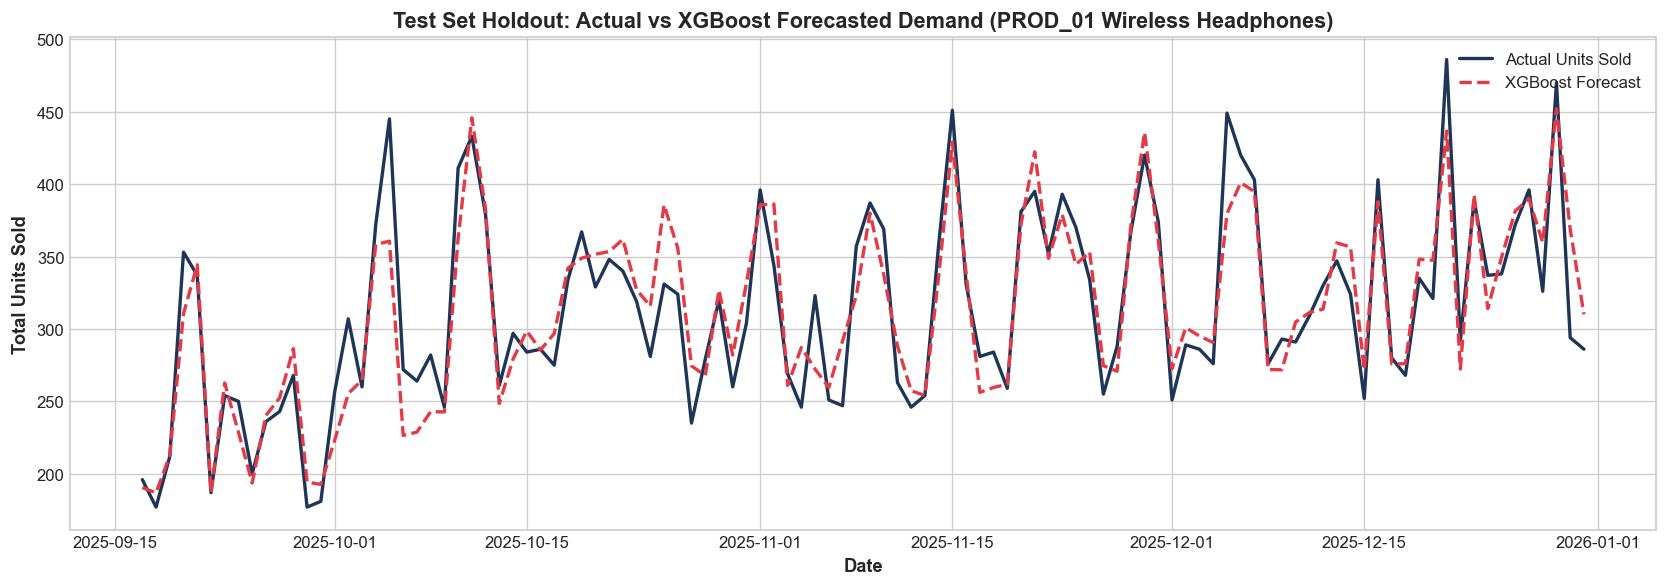

In [6]:
test_results = test_df.copy()
test_results['Actual_Demand'] = y_test
test_results['Forecast_XGBoost'] = np.round(y_xgb_test, 1)
test_results['Forecast_Error'] = test_results['Forecast_XGBoost'] - test_results['Actual_Demand']

# Save forecast outputs
os.makedirs("outputs", exist_ok=True)
test_results[['Date', 'Product_ID', 'Product_Name', 'Store_ID', 'Category', 'Our_Price', 'Actual_Demand', 'Forecast_XGBoost', 'Forecast_Error']].to_csv("outputs/forecast_results.csv", index=False)

# Plot actual vs forecast for top product
prod_sample = test_results[test_results['Product_ID'] == 'PROD_01'].groupby('Date').agg({
    'Actual_Demand': 'sum',
    'Forecast_XGBoost': 'sum'
}).reset_index()

plt.figure(figsize=(14, 5))
plt.plot(prod_sample['Date'], prod_sample['Actual_Demand'], label='Actual Units Sold', color='#1d3557', linewidth=2)
plt.plot(prod_sample['Date'], prod_sample['Forecast_XGBoost'], label='XGBoost Forecast', color='#e63946', linestyle='--', linewidth=2)
plt.title('Test Set Holdout: Actual vs XGBoost Forecasted Demand (PROD_01 Wireless Headphones)', fontsize=13, fontweight='bold')
plt.xlabel('Date', fontsize=11, fontweight='bold')
plt.ylabel('Total Units Sold', fontsize=11, fontweight='bold')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()


## 6. Model Explainability & Feature Importance
Analyzing key drivers of demand across pricing, competitive features, and seasonal temporal variables.


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_28160\1362064141.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp_df.head(15), x='Importance', y='Feature', palette='mako')


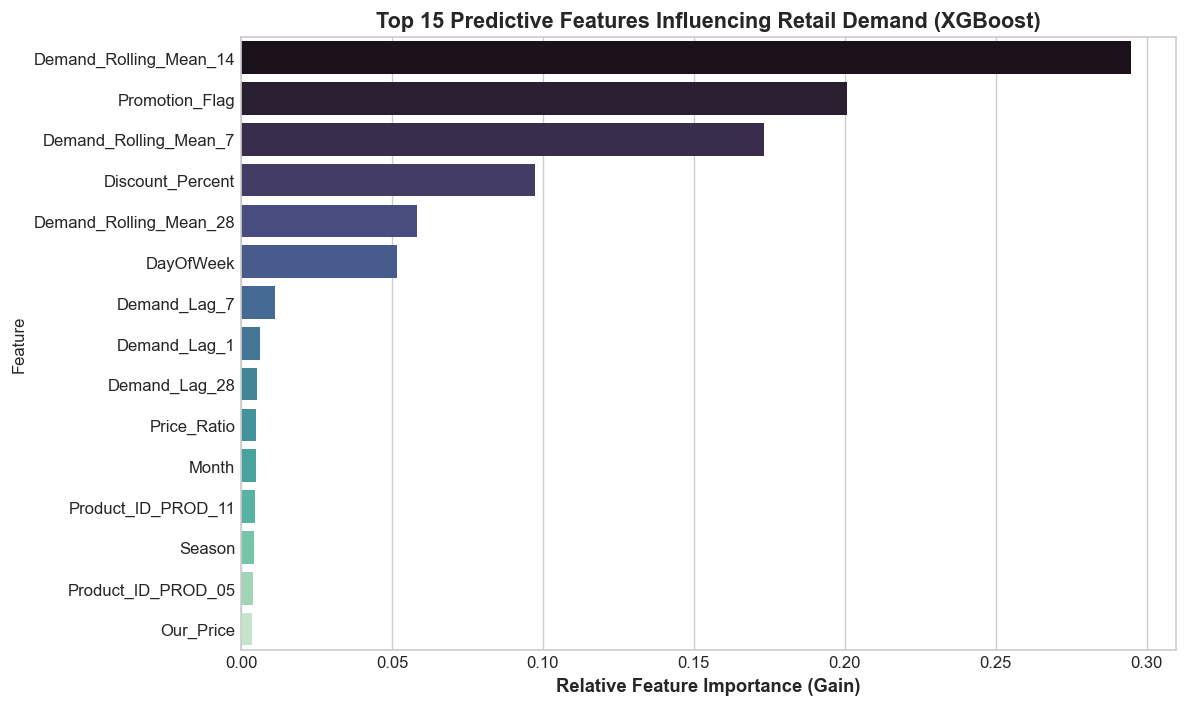

In [7]:
# Extract feature names from OneHotEncoder + Numerical cols
ohe_feature_names = list(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols))
all_feature_names = ohe_feature_names + numerical_cols

feature_importances = xgb_model.feature_importances_
feat_imp_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp_df.head(15), x='Importance', y='Feature', palette='mako')
plt.title('Top 15 Predictive Features Influencing Retail Demand (XGBoost)', fontsize=13, fontweight='bold')
plt.xlabel('Relative Feature Importance (Gain)', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


## 7. Model & Preprocessing Serialization
Saving the best model (`demand_model.pkl`), preprocessing pipeline (`preprocessing_pipeline.pkl`), feature schema, and evaluation metrics for downstream use in Notebook 03.


In [8]:
save_model_artifacts(
    model=xgb_model,
    preprocessor=preprocessor,
    feature_names=feature_metadata,
    metrics_df=metrics_df,
    models_dir="models",
    outputs_dir="outputs"
)
print("Demand forecasting pipeline successfully trained and serialized.")


Artifacts successfully saved to 'models/' and 'outputs/'.
Demand forecasting pipeline successfully trained and serialized.
